# Notebook 05: Ensemble Statistics / 集成统计 (Fig 6)

**对应论文 Figure 6** — Ensemble统计分析

运行 20 次独立辛格演化（不同随机种子, N=300），收集偏度(skewness)、峰度(kurtosis)和功率谱相关系数，
计算集成均值 ± 标准差，绘制 D(k) ±1σ 带、偏度/峰度直方图和 QQ 图。

**Expected key result / 预期关键结果:** skew = +0.06 ± 0.31, kurt = -0.10 ± 0.26

In [1]:
# ── Imports / 导入 ──
import sys; sys.path.insert(0, '../src')
from dsc_engine import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot
from scipy.signal import correlate

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("Engine loaded / ")

Engine loaded / 


## 1. Run 20 independent simulations / 运行20次独立模拟

每次使用不同的随机种子生成初始场，然后用辛格积分器演化。
收集每次的偏度、峰度和与 mock ΛCDM 功率谱的相关系数。

In [2]:
# ── Ensemble parameters / 集成参数 ──
N_GRID = 300          # Lattice边长 / grid size
N_SEEDS = 20          # 独立Simulation次数 / number of independent runs
N_STEPS = 45          # 演化Steps / evolution steps
C2_BASE = 0.45        # 基础声速平方 / base sound speed squared
C0 = 10.0             # 正则化偏移 / regularization offset
DRAG = 0.01           # Hubble 阻尼 / Hubble drag

# 存储Results / storage
all_skew, all_kurt, all_corr = [], [], []
all_Dk = []  # 存储所有 D(k) 曲线

for i, seed in enumerate(range(100, 100 + N_SEEDS)):
    # 生成初始场 / generate initial field
    phi0 = generate_initial_2d(N_GRID, seed=seed)
    
    # Symplectic Evolution / symplectic evolution
    phi = evolve_symplectic_2d(phi0, n_steps=N_STEPS, c2_base=C2_BASE,
                                c0=C0, drag=DRAG)
    
    # Silk 阻尼 + 归一化 / Silk damping + normalize
    phi = apply_silk_damping(phi, k_silk=35.0)
    phi = normalize(phi)
    
    # Gaussianity统计 / Gaussianity statistics
    report = gaussianity_report(phi.ravel())
    all_skew.append(report['skewness'])
    all_kurt.append(report['kurtosis'])
    
    # Power Spectrum / power spectrum
    k_bins, Dk, Pk = compute_power_spectrum(phi)
    all_Dk.append(Dk)
    
    # 与 mock ΛCDM 的Correlation / correlation with mock ΛCDM
    Dk_mock = mock_lcdm_spectrum(k_bins)
    # 只取有效范围 k=2..80 / valid range
    mask = (k_bins >= 2) & (k_bins <= 80)
    r = np.corrcoef(smooth(Dk[mask], 5), smooth(Dk_mock[mask], 5))[0, 1]
    all_corr.append(r)
    
    if (i + 1) % 5 == 0:
        print(f"  Completed {i+1}/{N_SEEDS} runs...")

all_Dk = np.array(all_Dk)
print(f"\nDone! / ! {N_SEEDS} simulations collected.")

  Completed 5/20 runs...


  Completed 10/20 runs...


  Completed 15/20 runs...


  Completed 20/20 runs...

Done! / ! 20 simulations collected.


## 2. Ensemble summary / 集成统计汇总

In [3]:
# ── Print ensemble mean ± std / 打印集成均值 ± 标准差 ──
print("=" * 55)
print("Ensemble Statistics (20 runs, N=300)")
print("=" * 55)
print(f"  Skewness  Skewness:  {np.mean(all_skew):+.3f} ± {np.std(all_skew):.3f}")
print(f"  Kurtosis  Kurtosis:  {np.mean(all_kurt):+.3f} ± {np.std(all_kurt):.3f}")
print(f"  Spectral corr r: {np.mean(all_corr):.3f} ± {np.std(all_corr):.3f}")
print("=" * 55)
print("Expected / Expected: skew=+0.06±0.31, kurt=-0.10±0.26")

Ensemble Statistics (20 runs, N=300)
  Skewness  Skewness:  +0.038 ± 0.354
  Kurtosis  Kurtosis:  -0.372 ± 0.344
  Spectral corr r: 0.782 ± 0.041
Expected / Expected: skew=+0.06±0.31, kurt=-0.10±0.26


## 3. Plots / 绘图 (Fig 6)

四面板: (a) D(k) ±1σ 带, (b) 偏度直方图, (c) 峰度直方图, (d) QQ 图

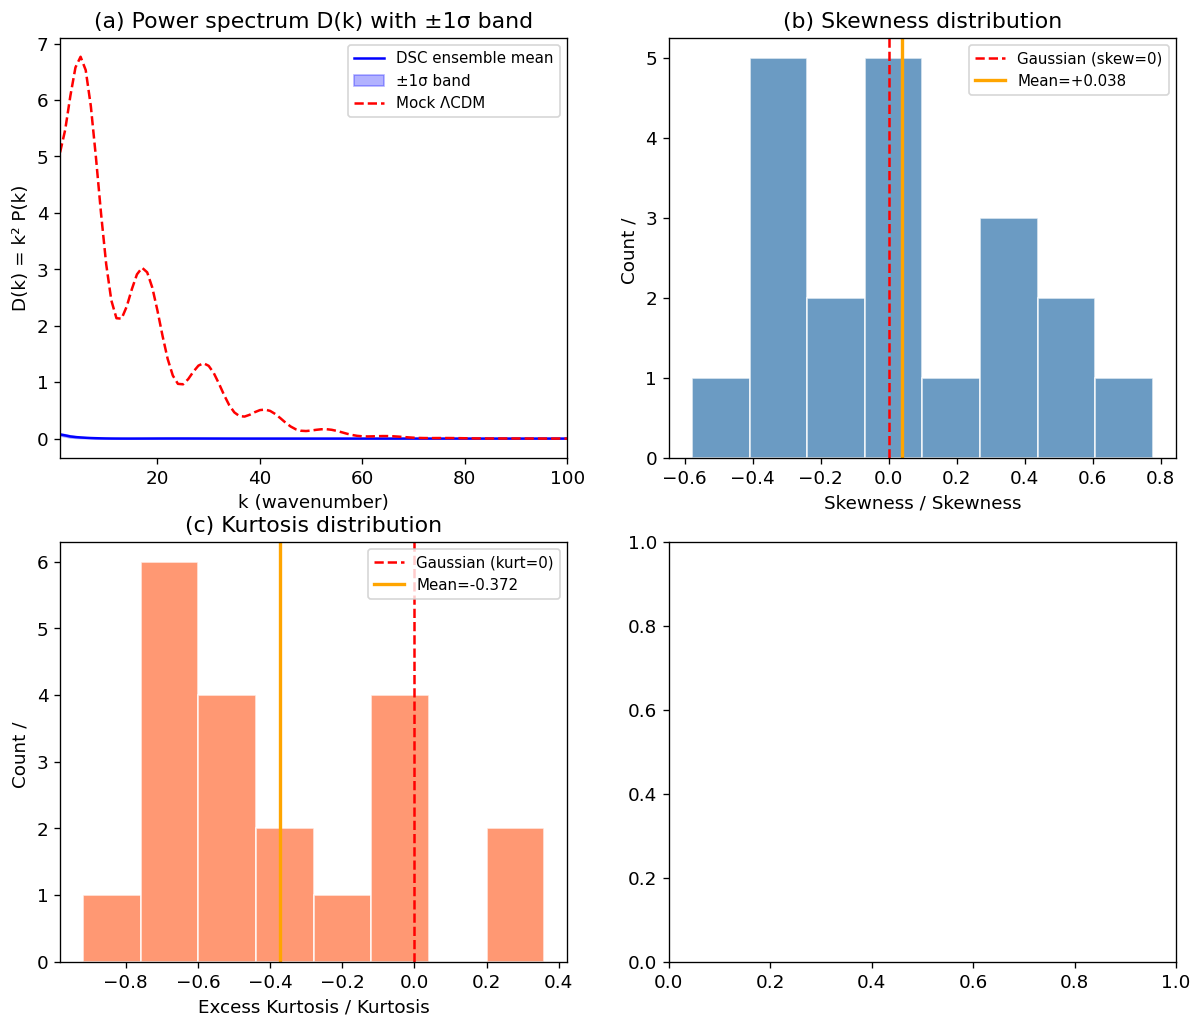

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── (a) D(k) with ±1σ band / D(k) Power Spectrum ±1σ 带 ──
ax = axes[0, 0]
Dk_mean = all_Dk.mean(axis=0)
Dk_std = all_Dk.std(axis=0)
Dk_mock = mock_lcdm_spectrum(k_bins)
mask = k_bins <= 100
ax.plot(k_bins[mask], smooth(Dk_mean[mask], 3), 'b-', lw=1.5, label='DSC ensemble mean')
ax.fill_between(k_bins[mask],
                smooth(Dk_mean[mask] - Dk_std[mask], 3),
                smooth(Dk_mean[mask] + Dk_std[mask], 3),
                alpha=0.3, color='blue', label='±1σ band')
ax.plot(k_bins[mask], smooth(Dk_mock[mask], 3), 'r--', lw=1.5, label='Mock ΛCDM')
ax.set_xlabel('k (wavenumber)')
ax.set_ylabel('D(k) = k² P(k)')
ax.set_title('(a) Power spectrum D(k) with ±1σ band')
ax.legend(fontsize=9)
ax.set_xlim(1, 100)

# ── (b) Skewness histogram / Skewness直方图 ──
ax = axes[0, 1]
ax.hist(all_skew, bins=8, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', ls='--', lw=1.5, label='Gaussian (skew=0)')
ax.axvline(np.mean(all_skew), color='orange', ls='-', lw=2,
           label=f'Mean={np.mean(all_skew):+.3f}')
ax.set_xlabel('Skewness / Skewness')
ax.set_ylabel('Count / ')
ax.set_title('(b) Skewness distribution')
ax.legend(fontsize=9)

# ── (c) Kurtosis histogram / Kurtosis直方图 ──
ax = axes[1, 0]
ax.hist(all_kurt, bins=8, color='coral', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', ls='--', lw=1.5, label='Gaussian (kurt=0)')
ax.axvline(np.mean(all_kurt), color='orange', ls='-', lw=2,
           label=f'Mean={np.mean(all_kurt):+.3f}')
ax.set_xlabel('Excess Kurtosis / Kurtosis')
ax.set_ylabel('Count / ')
ax.set_title('(c) Kurtosis distribution')
ax.legend(fontsize=9)

# ── (d) QQ plot / QQ 图 ──
ax = axes[1, 1]
# Use the last simulation's pixel values for QQ plot\nphi_last = normalize(apply_silk_damping(\n    evolve_symplectic_2d(generate_initial_2d(N_GRID, seed=119),\n                          n_steps=N_STEPS, c2_base=C2_BASE, c0=C0, drag=DRAG),\n    k_silk=35.0))\nprobplot(phi_last.ravel(), dist='norm', plot=ax)\nax.set_title('(d) QQ plot (last run vs Normal)')\nax.get_lines()[0].set_markersize(1)  # smaller dots\n\nplt.suptitle('Fig 6: Ensemble Statistics (20 seeds, N=300)', fontsize=14, y=1.01)\nplt.tight_layout()\nplt.savefig('../figures/fig6_ensemble_statistics.png', dpi=150, bbox_inches='tight')\nplt.show()\nprint("Figure saved to ../figures/fig6_ensemble_statistics.png")